# Model Training
Training and comparing multiple machine learning models to find the best
churn predictor. We compare Logistic Regression, Random Forest and XGBoost.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings('ignore')

# load engineered dataset
df = pd.read_csv('../data/processed/telco_engineered.csv')

print("Shape:", df.shape)
print("\nTarget Distribution:")
print(df['Churn Value'].value_counts())

Shape: (7043, 44)

Target Distribution:
Churn Value
0    5174
1    1869
Name: count, dtype: int64


### 1. Prepare Features and Target
Splitting data into features (X) and target (y), then into train and test sets.

In [2]:
# separating features and target
X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

# splitting into train and test sets - 80/20 split
# stratify ensures same churn ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                     random_state=42, 
                                                     stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(1))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(1))

Train size: (5634, 43)
Test size: (1409, 43)

Train target distribution:
Churn Value
0    73.5
1    26.5
Name: proportion, dtype: float64

Test target distribution:
Churn Value
0    73.5
1    26.5
Name: proportion, dtype: float64


### 2. Scale Features
Scaling numerical features for Logistic Regression.
Tree based models like Random Forest and XGBoost don't need scaling
but we scale for consistency.

In [3]:
# scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# saving scaler for use in streamlit app later
joblib.dump(scaler, '../src/models/scaler.pkl')
print("Scaler saved successfully.")

Scaler saved successfully.


### 3. Train Models
Training Logistic Regression, Random Forest and XGBoost with class_weight='balanced'
to handle the class imbalance.

In [4]:
# defining all three models
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', 
                                               max_iter=1000, 
                                               random_state=42),
    
    'Random Forest': RandomForestClassifier(class_weight='balanced', 
                                             n_estimators=100, 
                                             random_state=42),
    
    'XGBoost': XGBClassifier(scale_pos_weight=5174/1869,  # handles imbalance in xgb
                              n_estimators=100,
                              random_state=42,
                              eval_metric='logloss')
}

# training all models
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.


### 4. Evaluate Models
Comparing all three models using precision, recall, F1-score and ROC-AUC.
For churn prediction, recall is most important - we want to catch as many 
churners as possible before they leave.

In [5]:
# evaluating all models and storing results
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        'AUC': round(auc, 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'F1 Score': round(report['1']['f1-score'], 4)
    }
    
    print(f"\n{name}")
    print("-" * 40)
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))


Logistic Regression
----------------------------------------
ROC-AUC  : 0.8528
              precision    recall  f1-score   support

    No Churn       0.91      0.74      0.81      1035
       Churn       0.52      0.79      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409


Random Forest
----------------------------------------
ROC-AUC  : 0.8352
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.63      0.48      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409


XGBoost
----------------------------------------
ROC-AUC  : 0.8338
              precision    recall  f1-score   support

    No Churn       0.88      0.82      0.85      1035
       Churn   

### 5. Confusion Matrix
Visualizing how each model performs in terms of true/false positives and negatives.

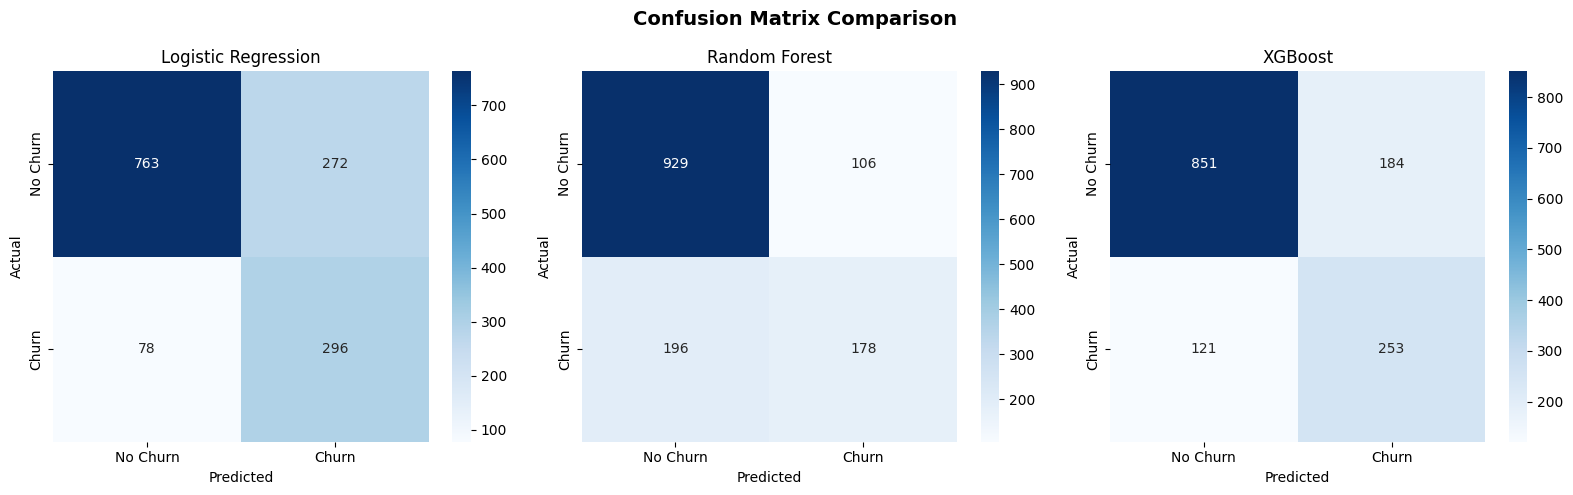

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'])
    axes[i].set_title(f'{name}')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Checking Model Fitting
Comparing train and test scores to detect overfitting or underfitting.
A big gap between train and test score means the model is overfitting.

In [7]:
print("Train vs Test Score Comparison:")
print("-" * 50)

for name, model in trained_models.items():
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    diff = train_score - test_score
    
    print(f"\n{name}")
    print(f"  Train Accuracy : {train_score:.4f}")
    print(f"  Test Accuracy  : {test_score:.4f}")
    print(f"  Difference     : {diff:.4f} {'⚠ Overfitting' if diff > 0.05 else '✓ Good Fit'}")

Train vs Test Score Comparison:
--------------------------------------------------

Logistic Regression
  Train Accuracy : 0.7671
  Test Accuracy  : 0.7516
  Difference     : 0.0155 ✓ Good Fit

Random Forest
  Train Accuracy : 1.0000
  Test Accuracy  : 0.7857
  Difference     : 0.2143 ⚠ Overfitting

XGBoost
  Train Accuracy : 0.9560
  Test Accuracy  : 0.7835
  Difference     : 0.1724 ⚠ Overfitting


### 7. Hyperparameter Tuning
Tuning Random Forest and XGBoost to fix overfitting.
Using cross-validation to find the best parameters.

In [8]:
from sklearn.model_selection import GridSearchCV

# tuning Random Forest - limiting tree depth and increasing min samples to reduce overfitting
rf_params = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20, 30],
    'n_estimators': [100, 200]
}

rf_grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', 
                                               random_state=42),
                       rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

rf_grid.fit(X_train_scaled, y_train)
print("Best RF Params:", rf_grid.best_params_)
print("Best RF AUC:", round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best RF Params: {'max_depth': 10, 'min_samples_split': 30, 'n_estimators': 200}
Best RF AUC: 0.8583


In [9]:
# tuning XGBoost - controlling depth and learning rate to reduce overfitting
xgb_params = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200]
}

xgb_grid = GridSearchCV(XGBClassifier(scale_pos_weight=5174/1869,
                                       random_state=42,
                                       eval_metric='logloss'),
                        xgb_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)

xgb_grid.fit(X_train_scaled, y_train)
print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB AUC:", round(xgb_grid.best_score_, 4))

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best XGB Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best XGB AUC: 0.8616


In [10]:
# retraining with best parameters
tuned_models = {
    'Logistic Regression': trained_models['Logistic Regression'],
    
    'Random Forest Tuned': RandomForestClassifier(class_weight='balanced',
                                                   max_depth=10,
                                                   min_samples_split=30,
                                                   n_estimators=200,
                                                   random_state=42),
    
    'XGBoost Tuned': XGBClassifier(scale_pos_weight=5174/1869,
                                    learning_rate=0.05,
                                    max_depth=3,
                                    n_estimators=100,
                                    random_state=42,
                                    eval_metric='logloss')
}

# training tuned models
for name, model in tuned_models.items():
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Random Forest Tuned trained successfully.
XGBoost Tuned trained successfully.


In [11]:
print("Train vs Test Score After Tuning:")
print("-" * 50)

for name, model in tuned_models.items():
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    diff = train_score - test_score
    
    print(f"\n{name}")
    print(f"  Train Accuracy : {train_score:.4f}")
    print(f"  Test Accuracy  : {test_score:.4f}")
    print(f"  Difference     : {diff:.4f} {'⚠ Overfitting' if diff > 0.05 else '✓ Good Fit'}")

Train vs Test Score After Tuning:
--------------------------------------------------

Logistic Regression
  Train Accuracy : 0.7671
  Test Accuracy  : 0.7516
  Difference     : 0.0155 ✓ Good Fit

Random Forest Tuned
  Train Accuracy : 0.8195
  Test Accuracy  : 0.7771
  Difference     : 0.0423 ✓ Good Fit

XGBoost Tuned
  Train Accuracy : 0.7710
  Test Accuracy  : 0.7438
  Difference     : 0.0272 ✓ Good Fit


In [12]:
# final evaluation of all tuned models
print("Final Model Comparison:")
print("-" * 60)

final_results = {}

for name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    final_results[name] = {
        'AUC': round(auc, 4),
        'Precision': round(report['1']['precision'], 4),
        'Recall': round(report['1']['recall'], 4),
        'F1 Score': round(report['1']['f1-score'], 4)
    }
    
    print(f"\n{name}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  Precision: {report['1']['precision']:.4f}")
    print(f"  Recall   : {report['1']['recall']:.4f}")
    print(f"  F1 Score : {report['1']['f1-score']:.4f}")

# summary table
print("\n\nSummary Table:")
print(pd.DataFrame(final_results).T.to_string())

Final Model Comparison:
------------------------------------------------------------

Logistic Regression
  ROC-AUC  : 0.8528
  Precision: 0.5211
  Recall   : 0.7914
  F1 Score : 0.6285

Random Forest Tuned
  ROC-AUC  : 0.8518
  Precision: 0.5591
  Recall   : 0.7594
  F1 Score : 0.6440

XGBoost Tuned
  ROC-AUC  : 0.8513
  Precision: 0.5111
  Recall   : 0.7968
  F1 Score : 0.6228


Summary Table:
                        AUC  Precision  Recall  F1 Score
Logistic Regression  0.8528     0.5211  0.7914    0.6285
Random Forest Tuned  0.8518     0.5591  0.7594    0.6440
XGBoost Tuned        0.8513     0.5111  0.7968    0.6228


In [13]:
# saving the final selected model and all tuned models
joblib.dump(tuned_models['Random Forest Tuned'], '../src/models/final_model.pkl')
joblib.dump(tuned_models['Logistic Regression'], '../src/models/logistic_model.pkl')
joblib.dump(tuned_models['XGBoost Tuned'], '../src/models/xgboost_model.pkl')

# saving feature names for streamlit app
import json
feature_names = X_train.columns.tolist()
with open('../src/models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("All models saved successfully.")
print("Feature names saved successfully.")

All models saved successfully.
Feature names saved successfully.


### 8. ROC Curve - Tuned Models
Visualizing the final performance of all three tuned models.

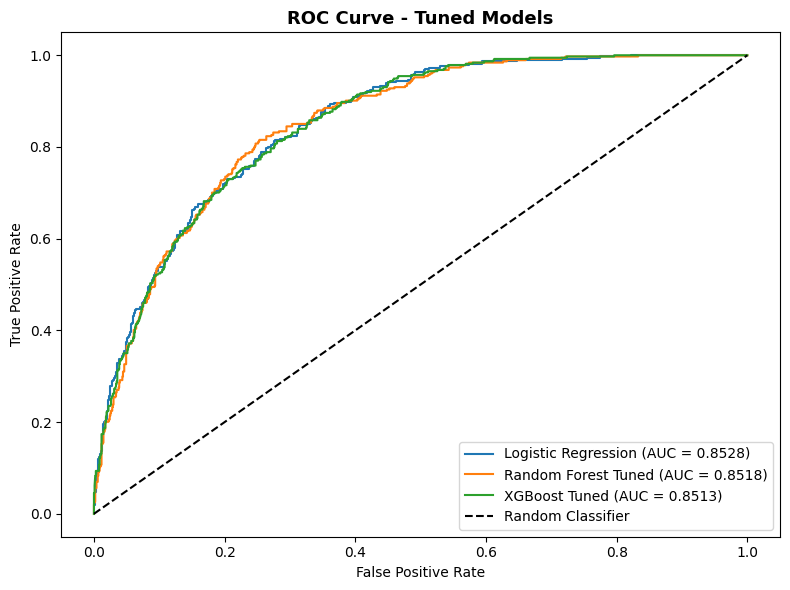

In [14]:
plt.figure(figsize=(8, 6))

for name, model in tuned_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Models', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary
- Trained Logistic Regression, Random Forest and XGBoost with class_weight='balanced'
- Detected overfitting in Random Forest and XGBoost - fixed with hyperparameter tuning
- All three models achieved similar ROC-AUC of ~0.85 after tuning
- Selected Random Forest Tuned as final model - best F1 (0.6440) and Precision (0.5591)
- All models and scaler saved to src/models/ for use in Streamlit app